In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np

In [2]:
#Loading and making the melamchi dataset for flood prediction 

df_melamchi_waterFlow = pd.read_csv("Datasets/melamchi_waterflow.csv")
df_melamchi_waterFlow.rename(columns={'Values': 'WaterFlow','Dates':'Date'},inplace=True)

df_melamchi_weather = pd.read_csv('Datasets/melamchi_weather.csv')
df_melamchi_weather.rename(columns={'YEAR':'Date'},inplace=True)

date_string_weather = df_melamchi_weather['Date'].astype(str) + ' '+ df_melamchi_weather['DOY'].astype(str) 

df_melamchi_waterFlow['Date'] = pd.to_datetime(df_melamchi_waterFlow['Date'])
df_melamchi_weather['Date'] = pd.to_datetime(date_string_weather, format="%Y %j")

df_melamchi_weather.drop(columns='DOY',inplace=True)

df_melamchi = pd.merge_asof(df_melamchi_weather,df_melamchi_waterFlow,on='Date')
df_melamchi.drop(columns='Date',inplace=True)

df_melamchi.rename(columns={
    'PRECTOTCORR': 'Rainfall', 
    'T2M': 'Temperature',
    'RH2M': 'Relative_Humidity'
},inplace=True)

#Creating flood occurrence label
flood_threshold = df_melamchi['WaterFlow'].quantile(0.95)
df_melamchi['floodOccurrence'] = (df_melamchi['WaterFlow'] > flood_threshold).astype(int)

#Separating the data for training and validation
y = df_melamchi.pop('floodOccurrence')
X = df_melamchi

separating_idx = int(len(df_melamchi) * 0.8)
X_train_raw  = X.iloc[:separating_idx]
y_train_raw = y.iloc[:separating_idx]

X_val_raw = X.iloc[separating_idx:]
y_val_raw = y.iloc[separating_idx:]


#Scaling the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

#Changing to tensors
X_train_tensors = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensors = torch.tensor(y_train_raw.values,dtype=torch.float32).unsqueeze(1) #to make the size [N,1]

X_val_tensors = torch.tensor(X_val_scaled,dtype=torch.float32)
y_val_tensors = torch.tensor(y_val_raw.values,dtype=torch.float32).unsqueeze(1) 


In [3]:
#model definition
class NeuralModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.hidden1 = nn.Linear(input_size,64)
        self.hidden2 = nn.Linear(64,64)
        self.output = nn.Linear(64,1)
        self.relu = nn.ReLU()
        
    def forward(self,x):
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.hidden2(x)
        x = self.relu(x)
        return self.output(x)
 
#training process
def train_model(model,X_train,X_val,y_train,y_val,epochs,lr,criterion,patience=30):
    optimizer = optim.Adam(model.parameters(),lr=lr)
    patience_counter = 0
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        predicted = model(X_train)
        train_loss = criterion(predicted,y_train)
        
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predicted = model(X_val)
            val_loss = criterion(val_predicted,y_val)
            
        #Check for improvement
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            # Save the best model state dynamically
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pth")
        else:
            patience_counter += 1

        # Print metrics every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
            
        # Break early if the model stops improving
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
            break
    

In [4]:
#Flood prediction model
input_features = X_train_tensors.shape[1]
flood_model = NeuralModel(input_size=input_features)
criterion_binary = nn.BCEWithLogitsLoss()
train_model(
    model=flood_model,
    X_train=X_train_tensors,
    X_val=X_val_tensors,
    y_train=y_train_tensors,
    y_val=y_val_tensors,
    epochs=500,
    lr=0.001,
    criterion=criterion_binary
)

Epoch [1/500] -> Train Loss: 0.6867 | Val Loss: 0.6691
Epoch [5/500] -> Train Loss: 0.6347 | Val Loss: 0.6111
Epoch [10/500] -> Train Loss: 0.5733 | Val Loss: 0.5457
Epoch [15/500] -> Train Loss: 0.5132 | Val Loss: 0.4850
Epoch [20/500] -> Train Loss: 0.4546 | Val Loss: 0.4273
Epoch [25/500] -> Train Loss: 0.3965 | Val Loss: 0.3718
Epoch [30/500] -> Train Loss: 0.3406 | Val Loss: 0.3195
Epoch [35/500] -> Train Loss: 0.2885 | Val Loss: 0.2715
Epoch [40/500] -> Train Loss: 0.2421 | Val Loss: 0.2293
Epoch [45/500] -> Train Loss: 0.2028 | Val Loss: 0.1938
Epoch [50/500] -> Train Loss: 0.1714 | Val Loss: 0.1652
Epoch [55/500] -> Train Loss: 0.1466 | Val Loss: 0.1424
Epoch [60/500] -> Train Loss: 0.1270 | Val Loss: 0.1245
Epoch [65/500] -> Train Loss: 0.1113 | Val Loss: 0.1104
Epoch [70/500] -> Train Loss: 0.0985 | Val Loss: 0.0991
Epoch [75/500] -> Train Loss: 0.0881 | Val Loss: 0.0898
Epoch [80/500] -> Train Loss: 0.0794 | Val Loss: 0.0818
Epoch [85/500] -> Train Loss: 0.0720 | Val Loss: 0

In [5]:
torch.save(flood_model.state_dict(),"flood_model.pth")

In [6]:
#Preparing the chisepani dataset 

df_chisepani_ratedischarge = pd.read_csv("Datasets/chisapani_ratedischarge.csv")
df_chisepani_weather = pd.read_csv("Datasets/chisepani_weather.csv")

date_string = (df_chisepani_weather['YEAR'].astype(str) + ' ' + df_chisepani_weather['DOY'].astype(str))
df_chisepani_weather['Date'] = pd.to_datetime(date_string,format="%Y %j") 
df_chisepani_ratedischarge['datetime'] = pd.to_datetime(df_chisepani_ratedischarge['datetime'])

df_chisepani_weather.drop(columns=['DOY','YEAR'],inplace=True)
df_chisepani_ratedischarge.rename(columns={'datetime':'Date','discharge_cms':'volumetricFlowRate'},inplace=True)

df_chisepani = pd.merge_asof(df_chisepani_weather,df_chisepani_ratedischarge,on="Date",direction="backward")
df_chisepani.rename(columns={
    'PRECTOTCORR': 'Rainfall', 
    'T2M': 'Temperature',
    'RH2M': 'Relative_Humidity'
},inplace=True)
df_chisepani.drop(columns='Date',inplace=True)

#Separating the data for training and validation
y_c = df_chisepani.pop('volumetricFlowRate') #_c is added to make the variable name separate for chisepani dataset
X_c = df_chisepani

separating_idx = int(len(df_chisepani) * 0.8)
X_train_raw_c  = X_c.iloc[:separating_idx]
y_train_raw_c = y_c.iloc[:separating_idx]

X_val_raw_c = X_c.iloc[separating_idx:]
y_val_raw_c = y_c.iloc[separating_idx:]


#Scaling the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled_c = scaler.fit_transform(X_train_raw_c)
X_val_scaled_c = scaler.transform(X_val_raw_c)

y_train_scaled_c = scaler_y.fit_transform(y_train_raw_c.values.reshape(-1, 1)) #type: ignore
y_val_scaled_c = scaler_y.transform(y_val_raw_c.values.reshape(-1, 1)) #type: ignore

#Changing to tensors
X_train_tensors_c = torch.tensor(X_train_scaled_c,dtype=torch.float32)
y_train_tensors_c = torch.tensor(y_train_scaled_c,dtype=torch.float32) #to make the size [N,1]

X_val_tensors_c = torch.tensor(X_val_scaled_c,dtype=torch.float32)
y_val_tensors_c = torch.tensor(y_val_scaled_c,dtype=torch.float32) 


In [7]:
inputfeatures = X_train_tensors_c.shape[1]
flowrate_model = NeuralModel(input_size=inputfeatures)
criterion = nn.MSELoss()
train_model(
    model=flowrate_model,
    X_train=X_train_tensors_c,
    X_val=X_val_tensors_c,
    y_train=y_train_tensors_c,
    y_val=y_val_tensors_c,
    epochs=500,
    lr=0.001,
    criterion=criterion
)

Epoch [1/500] -> Train Loss: 1.0874 | Val Loss: 1.3602
Epoch [5/500] -> Train Loss: 0.8906 | Val Loss: 1.1183
Epoch [10/500] -> Train Loss: 0.6901 | Val Loss: 0.8714
Epoch [15/500] -> Train Loss: 0.5290 | Val Loss: 0.6707
Epoch [20/500] -> Train Loss: 0.4108 | Val Loss: 0.5204
Epoch [25/500] -> Train Loss: 0.3372 | Val Loss: 0.4201
Epoch [30/500] -> Train Loss: 0.2984 | Val Loss: 0.3631
Epoch [35/500] -> Train Loss: 0.2747 | Val Loss: 0.3305
Epoch [40/500] -> Train Loss: 0.2564 | Val Loss: 0.3067
Epoch [45/500] -> Train Loss: 0.2443 | Val Loss: 0.2904
Epoch [50/500] -> Train Loss: 0.2354 | Val Loss: 0.2766
Epoch [55/500] -> Train Loss: 0.2267 | Val Loss: 0.2617
Epoch [60/500] -> Train Loss: 0.2198 | Val Loss: 0.2477
Epoch [65/500] -> Train Loss: 0.2151 | Val Loss: 0.2377
Epoch [70/500] -> Train Loss: 0.2110 | Val Loss: 0.2308
Epoch [75/500] -> Train Loss: 0.2077 | Val Loss: 0.2246
Epoch [80/500] -> Train Loss: 0.2049 | Val Loss: 0.2187
Epoch [85/500] -> Train Loss: 0.2024 | Val Loss: 0

In [12]:
%pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


   FLOOD PREDICTION SYSTEM — FULL MODEL EVALUATION

[1/4] Loading & preprocessing Melamchi dataset ...
       Validation samples: 3288

[2/4] Loading & preprocessing Chisapani dataset ...
       Validation samples: 3288

[3/4] Evaluating Melamchi Flood Classifier ...

──────────────── TEST 1 — MELAMCHI FLOOD CLASSIFIER ────────────────
  ✅ PASS  Loaded 'flood_model.pth'

────────────────────────── Sanity Checks ──────────────────────────
  ✅ PASS  Model predicts both classes (0 and 1).
  ⚠️  WARN  95.6% of outputs are near-saturated (< 0.01 or > 0.99).
  INFO  Validation flood rate: 4.2%  (flood threshold = 1.57 m³/s)

────────────────────── Classification Report ──────────────────────
              precision    recall  f1-score   support

    No Flood     0.9968    1.0000    0.9984      3149
       Flood     1.0000    0.9281    0.9627       139

    accuracy                         0.9970      3288
   macro avg     0.9984    0.9640    0.9806      3288
weighted avg     0.9970    0.9970

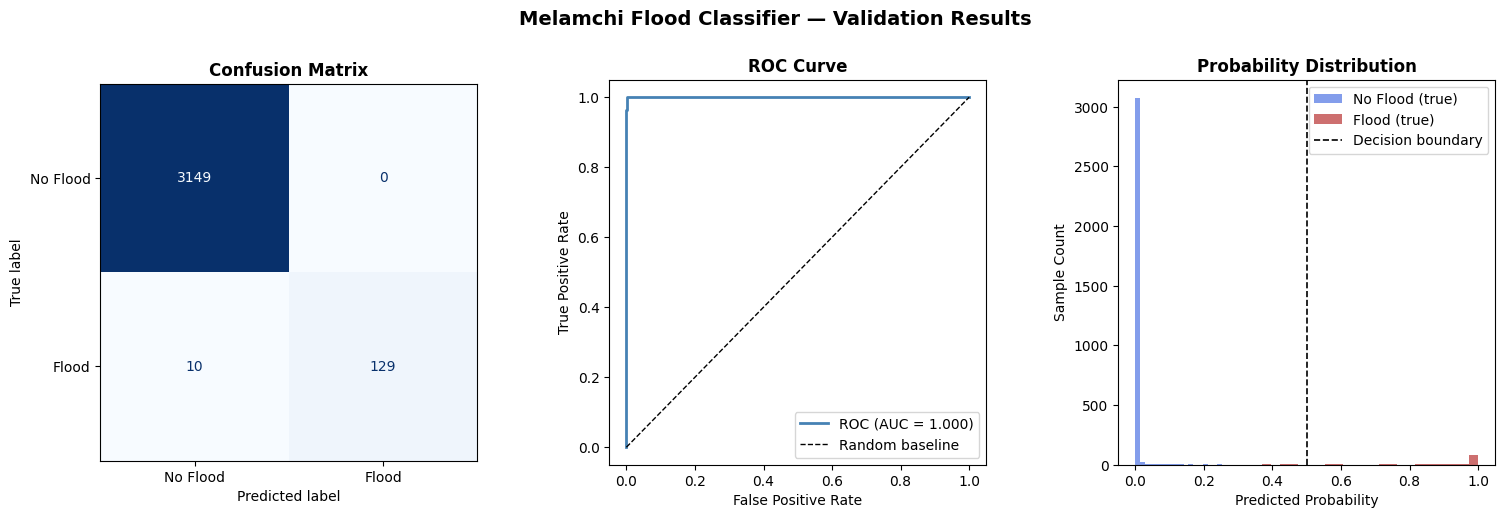

  Plots saved → melamchi_evaluation.png

[4/4] Evaluating Chisapani Flow Rate Regressor ...

────────────── TEST 2 — CHISAPANI FLOW RATE REGRESSOR ──────────────
  ✅ PASS  Loaded 'NeuralModel.pth'

────────────────────────── Sanity Checks ──────────────────────────
  ✅ PASS  No NaN values in predictions.
  ✅ PASS  Prediction range covers 63% of the observed range.
  ⚠️  WARN  Systematic bias detected: mean error = +100.75 cms (over-predicting on average).

──────────────────────── Summary Scorecard ────────────────────────
  MAE  (Mean Abs Error)    : 353.91 cms  ⚠️  WARN
  RMSE (Root Mean Sq Err)  : 569.31 cms  ⚠️  WARN
  R²   (Coeff. of Determ.) : 0.8595    ✅ PASS
  MAPE (Mean Abs % Error)  : 35.48%   ⚠️  WARN
  NSE  (Nash-Sutcliffe)    : 0.8595    (excellent)

──────── Peak Flow Analysis  (top 5% of observed discharge) ────────
  Samples in top-5% peak   : 165
  Peak MAE                 : 1192.87 cms
  Peak RMSE                : 1371.93 cms
  ⚠️  WARN  Model struggles significantly 

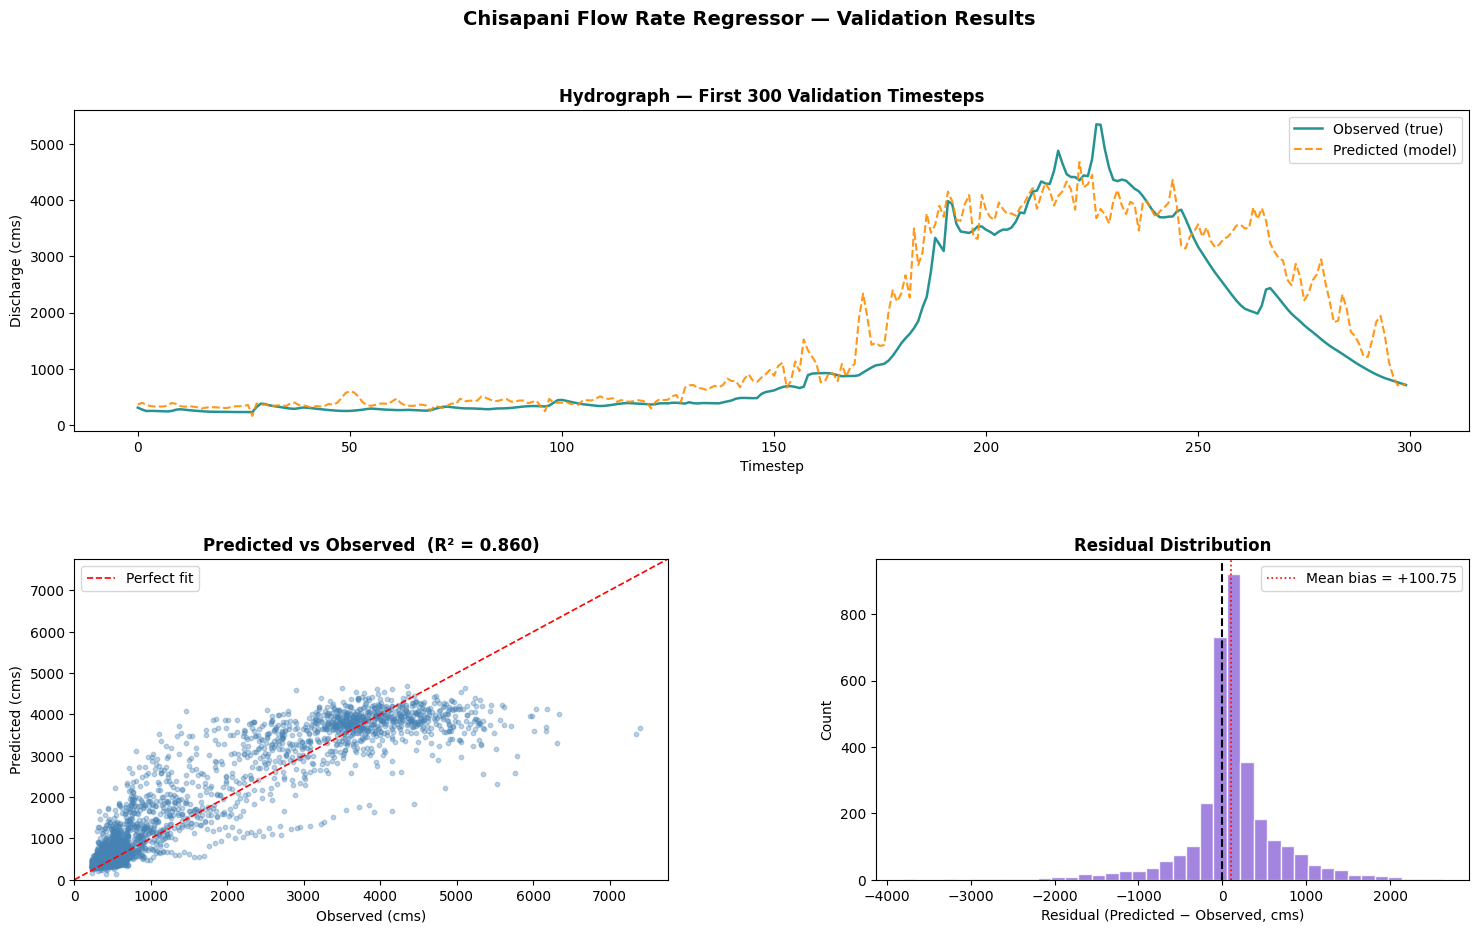

  Plots saved → chisapani_evaluation.png

   EVALUATION COMPLETE
   Output plots: melamchi_evaluation.png | chisapani_evaluation.png


In [14]:
"""
=============================================================================
  MODEL EVALUATION SCRIPT
  Melamchi Flood Classifier  &  Chisapani Flow Rate Regressor
=============================================================================
  Run from the project root (same directory as your Datasets/ folder):
      python evaluate_models.py
  
  Required .pth files:  flood_model.pth  |  NeuralModel.pth (flowrate)
  Required datasets  :  Datasets/melamchi_waterflow.csv
                        Datasets/melamchi_weather.csv
                        Datasets/chisapani_ratedischarge.csv
                        Datasets/chisepani_weather.csv
=============================================================================
"""

import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  MODEL DEFINITION  (must match training architecture exactly)
# ─────────────────────────────────────────────────────────────────────────────

class NeuralModel(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.hidden1 = nn.Linear(input_size, 64)
        self.hidden2 = nn.Linear(64, 64)
        self.output  = nn.Linear(64, 1)
        self.relu    = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        return self.output(x)


# ─────────────────────────────────────────────────────────────────────────────
# 1.  DATA PREPARATION  (mirrors your notebook exactly)
# ─────────────────────────────────────────────────────────────────────────────

def prepare_melamchi():
    """Return (X_val_tensors, y_val_tensors, flood_threshold) for Melamchi."""
    df_wf = pd.read_csv("Datasets/melamchi_waterflow.csv")
    df_wf.rename(columns={"Values": "WaterFlow", "Dates": "Date"}, inplace=True)

    df_wx = pd.read_csv("Datasets/melamchi_weather.csv")
    df_wx.rename(columns={"YEAR": "Date"}, inplace=True)

    date_str = df_wx["Date"].astype(str) + " " + df_wx["DOY"].astype(str)
    df_wf["Date"] = pd.to_datetime(df_wf["Date"])
    df_wx["Date"] = pd.to_datetime(date_str, format="%Y %j")
    df_wx.drop(columns="DOY", inplace=True)

    df = pd.merge_asof(df_wx, df_wf, on="Date")
    df.drop(columns="Date", inplace=True)
    df.rename(columns={"PRECTOTCORR": "Rainfall",
                       "T2M": "Temperature",
                       "RH2M": "Relative_Humidity"}, inplace=True)

    flood_threshold = df["WaterFlow"].quantile(0.95)
    df["floodOccurrence"] = (df["WaterFlow"] > flood_threshold).astype(int)

    y = df.pop("floodOccurrence")
    X = df

    split = int(len(X) * 0.8)
    X_train_raw, X_val_raw = X.iloc[:split], X.iloc[split:]
    y_train_raw, y_val_raw = y.iloc[:split], y.iloc[split:]

    scaler = StandardScaler()
    scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)

    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_raw.values, dtype=torch.float32).unsqueeze(1)

    return X_val_t, y_val_t, flood_threshold


def prepare_chisapani():
    """Return (X_val_tensors, y_val_tensors, scaler_y) for Chisapani."""
    df_rd = pd.read_csv("Datasets/chisapani_ratedischarge.csv")
    df_wx = pd.read_csv("Datasets/chisepani_weather.csv")

    date_str = df_wx["YEAR"].astype(str) + " " + df_wx["DOY"].astype(str)
    df_wx["Date"] = pd.to_datetime(date_str, format="%Y %j")
    df_rd["datetime"] = pd.to_datetime(df_rd["datetime"])
    df_wx.drop(columns=["DOY", "YEAR"], inplace=True)
    df_rd.rename(columns={"datetime": "Date",
                           "discharge_cms": "volumetricFlowRate"}, inplace=True)

    df = pd.merge_asof(df_wx, df_rd, on="Date", direction="backward")
    df.rename(columns={"PRECTOTCORR": "Rainfall",
                       "T2M": "Temperature",
                       "RH2M": "Relative_Humidity"}, inplace=True)
    df.drop(columns="Date", inplace=True)

    y_c = df.pop("volumetricFlowRate")
    X_c = df

    split = int(len(X_c) * 0.8)
    X_train_raw_c, X_val_raw_c = X_c.iloc[:split], X_c.iloc[split:]
    y_train_raw_c, y_val_raw_c = y_c.iloc[:split], y_c.iloc[split:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    scaler_X.fit_transform(X_train_raw_c)
    X_val_scaled_c = scaler_X.transform(X_val_raw_c)
    scaler_y.fit_transform(y_train_raw_c.values.reshape(-1, 1))
    y_val_scaled_c = scaler_y.transform(y_val_raw_c.values.reshape(-1, 1))

    X_val_t = torch.tensor(X_val_scaled_c, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_scaled_c,  dtype=torch.float32)

    return X_val_t, y_val_t, scaler_y


# ─────────────────────────────────────────────────────────────────────────────
# 2.  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

PASS = "✅ PASS"
FAIL = "❌ FAIL"
WARN = "⚠️  WARN"

def _load_model(path: str, input_size: int) -> NeuralModel | None:
    model = NeuralModel(input_size=input_size)
    try:
        model.load_state_dict(torch.load(path, map_location="cpu"))
        model.eval()
        print(f"  {PASS}  Loaded '{path}'")
        return model
    except FileNotFoundError:
        print(f"  {FAIL}  '{path}' not found — skipping this model.")
        return None
    except Exception as e:
        print(f"  {FAIL}  Could not load '{path}': {e}")
        return None


def _sep(title: str = "", width: int = 68):
    if title:
        pad = (width - len(title) - 2) // 2
        print("\n" + "─" * pad + f" {title} " + "─" * pad)
    else:
        print("─" * width)


# ─────────────────────────────────────────────────────────────────────────────
# 3.  MELAMCHI  —  FLOOD CLASSIFICATION EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_flood_classifier(X_val: torch.Tensor,
                               y_val: torch.Tensor,
                               threshold: float):
    _sep("TEST 1 — MELAMCHI FLOOD CLASSIFIER")

    model = _load_model("flood_model.pth", X_val.shape[1])
    if model is None:
        return

    with torch.no_grad():
        logits = model(X_val)
        probs  = torch.sigmoid(logits).numpy().flatten()
        preds  = (probs >= 0.5).astype(int)

    y_true = y_val.numpy().flatten().astype(int)

    # ── Sanity checks ──────────────────────────────────────────────────────
    _sep("Sanity Checks")

    unique_preds = np.unique(preds)
    if len(unique_preds) < 2:
        print(f"  {FAIL}  COLLAPSED OUTPUT — model only predicts class {unique_preds[0]}.")
        print("         Likely cause: class imbalance + insufficient training.")
    else:
        print(f"  {PASS}  Model predicts both classes (0 and 1).")

    if np.all((probs > 0.01) & (probs < 0.99)):
        print(f"  {PASS}  Probabilities are in a healthy mid-range (not saturated).")
    else:
        saturated = np.mean((probs < 0.01) | (probs > 0.99)) * 100
        print(f"  {WARN}  {saturated:.1f}% of outputs are near-saturated (< 0.01 or > 0.99).")

    class_balance = np.mean(y_true)
    print(f"  INFO  Validation flood rate: {class_balance*100:.1f}%  "
          f"(flood threshold = {threshold:.2f} m³/s)")

    # ── Core metrics ───────────────────────────────────────────────────────
    _sep("Classification Report")
    print(classification_report(y_true, preds,
                                 target_names=["No Flood", "Flood"],
                                 digits=4))

    from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
    acc   = accuracy_score(y_true, preds)
    f1    = f1_score(y_true, preds, zero_division=0)
    mcc   = matthews_corrcoef(y_true, preds)
    rocauc = auc(*roc_curve(y_true, probs)[:2])
    ap    = average_precision_score(y_true, probs)

    _sep("Summary Scorecard")
    print(f"  Accuracy          : {acc*100:6.2f}%   {PASS if acc > 0.80 else WARN}")
    print(f"  F1-Score (Flood)  : {f1:.4f}    {PASS if f1 > 0.60 else WARN}")
    print(f"  ROC-AUC           : {rocauc:.4f}    {PASS if rocauc > 0.75 else WARN}")
    print(f"  Avg Precision (AP): {ap:.4f}    {PASS if ap > 0.50 else WARN}")
    print(f"  Matthews CC (MCC) : {mcc:.4f}    "
          f"{'(strong)' if mcc > 0.5 else '(moderate)' if mcc > 0.2 else '(weak)'}")

    # ── Threshold sensitivity ──────────────────────────────────────────────
    _sep("Threshold Sensitivity")
    print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p_t = (probs >= t).astype(int)
        from sklearn.metrics import precision_score, recall_score
        pr = precision_score(y_true, p_t, zero_division=0)
        rc = recall_score(y_true, p_t, zero_division=0)
        f  = f1_score(y_true, p_t, zero_division=0)
        marker = "  ← default" if t == 0.50 else ""
        print(f"  {t:>10.2f}  {pr:>10.4f}  {rc:>8.4f}  {f:>8.4f}{marker}")

    # ── Plots ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # Confusion matrix
    ax0 = fig.add_subplot(gs[0])
    cm  = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["No Flood", "Flood"]).plot(
        ax=ax0, cmap="Blues", values_format="d", colorbar=False)
    ax0.set_title("Confusion Matrix", fontweight="bold")
    ax0.grid(False)

    # ROC curve
    ax1  = fig.add_subplot(gs[1])
    fpr, tpr, _ = roc_curve(y_true, probs)
    ax1.plot(fpr, tpr, color="steelblue", lw=2,
             label=f"ROC (AUC = {rocauc:.3f})")
    ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curve", fontweight="bold")
    ax1.legend(loc="lower right")

    # Probability distribution
    ax2 = fig.add_subplot(gs[2])
    ax2.hist(probs[y_true == 0], bins=30, alpha=0.65,
             label="No Flood (true)", color="royalblue")
    ax2.hist(probs[y_true == 1], bins=30, alpha=0.65,
             label="Flood (true)",    color="firebrick")
    ax2.axvline(0.5, color="black", linestyle="--", lw=1.2, label="Decision boundary")
    ax2.set_xlabel("Predicted Probability")
    ax2.set_ylabel("Sample Count")
    ax2.set_title("Probability Distribution", fontweight="bold")
    ax2.legend()

    fig.suptitle("Melamchi Flood Classifier — Validation Results",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.savefig("melamchi_evaluation.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("  Plots saved → melamchi_evaluation.png")


# ─────────────────────────────────────────────────────────────────────────────
# 4.  CHISAPANI  —  FLOW RATE REGRESSION EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_flow_regressor(X_val: torch.Tensor,
                             y_val: torch.Tensor,
                             scaler_y: StandardScaler):
    _sep("TEST 2 — CHISAPANI FLOW RATE REGRESSOR")

    model = _load_model("NeuralModel.pth", X_val.shape[1])
    if model is None:
        return

    with torch.no_grad():
        scaled_preds = model(X_val).numpy()

    # Inverse-transform back to real-world cubic-metres-per-second
    preds_cms = scaler_y.inverse_transform(scaled_preds).flatten()
    true_cms  = scaler_y.inverse_transform(y_val.numpy()).flatten()

    # ── Sanity checks ──────────────────────────────────────────────────────
    _sep("Sanity Checks")

    if np.any(np.isnan(preds_cms)):
        print(f"  {FAIL}  NaN values detected in predictions — training likely diverged.")
    else:
        print(f"  {PASS}  No NaN values in predictions.")

    pred_range = preds_cms.max() - preds_cms.min()
    true_range = true_cms.max()  - true_cms.min()
    coverage   = pred_range / true_range if true_range > 0 else 0
    if coverage < 0.30:
        print(f"  {WARN}  Prediction range is only {coverage*100:.0f}% of the true range "
              f"— model may be under-predicting peaks.")
    else:
        print(f"  {PASS}  Prediction range covers {coverage*100:.0f}% of the observed range.")

    bias = np.mean(preds_cms - true_cms)
    if abs(bias) > 0.05 * np.mean(true_cms):
        print(f"  {WARN}  Systematic bias detected: mean error = {bias:+.2f} cms "
              f"({'over' if bias > 0 else 'under'}-predicting on average).")
    else:
        print(f"  {PASS}  No significant systematic bias (mean error = {bias:+.2f} cms).")

    # ── Core metrics ───────────────────────────────────────────────────────
    mse  = mean_squared_error(true_cms, preds_cms)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true_cms, preds_cms)
    r2   = r2_score(true_cms, preds_cms)
    mape = np.mean(np.abs((true_cms - preds_cms) /
                           np.where(true_cms == 0, 1, true_cms))) * 100
    nse  = 1 - (np.sum((true_cms - preds_cms)**2) /
                 np.sum((true_cms - np.mean(true_cms))**2))  # Nash-Sutcliffe

    _sep("Summary Scorecard")
    print(f"  MAE  (Mean Abs Error)    : {mae:.2f} cms  {PASS if mae < 100 else WARN}")
    print(f"  RMSE (Root Mean Sq Err)  : {rmse:.2f} cms  {PASS if rmse < 150 else WARN}")
    print(f"  R²   (Coeff. of Determ.) : {r2:.4f}    "
          f"{PASS if r2 > 0.75 else WARN if r2 > 0.50 else FAIL}")
    print(f"  MAPE (Mean Abs % Error)  : {mape:.2f}%   "
          f"{PASS if mape < 20 else WARN if mape < 40 else FAIL}")
    print(f"  NSE  (Nash-Sutcliffe)    : {nse:.4f}    "
          f"{'(excellent)' if nse > 0.75 else '(satisfactory)' if nse > 0.5 else '(poor)'}")

    if r2 < 0.0:
        print(f"\n  {FAIL}  R² is negative — model is worse than predicting the mean.")
        print("         Consider: more data, feature engineering, or longer training.")

    # ── Peak flow analysis ─────────────────────────────────────────────────
    _sep("Peak Flow Analysis  (top 5% of observed discharge)")
    peak_mask  = true_cms > np.percentile(true_cms, 95)
    peak_mae   = mean_absolute_error(true_cms[peak_mask], preds_cms[peak_mask])
    peak_rmse  = np.sqrt(mean_squared_error(true_cms[peak_mask], preds_cms[peak_mask]))
    print(f"  Samples in top-5% peak   : {peak_mask.sum()}")
    print(f"  Peak MAE                 : {peak_mae:.2f} cms")
    print(f"  Peak RMSE                : {peak_rmse:.2f} cms")
    if peak_rmse > 2 * rmse:
        print(f"  {WARN}  Model struggles significantly on high-flow events.")
    else:
        print(f"  {PASS}  Model handles peak flows reasonably well.")

    # ── Plots ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

    # Hydrograph — first 300 samples
    ax0 = fig.add_subplot(gs[0, :])
    n   = min(300, len(true_cms))
    ax0.plot(true_cms[:n],  label="Observed (true)",     color="teal",
             lw=1.8, alpha=0.85)
    ax0.plot(preds_cms[:n], label="Predicted (model)",   color="darkorange",
             lw=1.5, linestyle="--", alpha=0.90)
    ax0.set_title("Hydrograph — First 300 Validation Timesteps", fontweight="bold")
    ax0.set_xlabel("Timestep")
    ax0.set_ylabel("Discharge (cms)")
    ax0.legend()

    # Scatter: predicted vs observed
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.scatter(true_cms, preds_cms, alpha=0.35, s=10, color="steelblue")
    lim = max(true_cms.max(), preds_cms.max()) * 1.05
    ax1.plot([0, lim], [0, lim], "r--", lw=1.2, label="Perfect fit")
    ax1.set_xlim(0, lim);  ax1.set_ylim(0, lim)
    ax1.set_xlabel("Observed (cms)");  ax1.set_ylabel("Predicted (cms)")
    ax1.set_title(f"Predicted vs Observed  (R² = {r2:.3f})", fontweight="bold")
    ax1.legend()

    # Residuals
    ax2  = fig.add_subplot(gs[1, 1])
    resid = preds_cms - true_cms
    ax2.hist(resid, bins=40, color="mediumpurple", edgecolor="white", alpha=0.85)
    ax2.axvline(0,    color="black", lw=1.5, linestyle="--")
    ax2.axvline(bias, color="red",   lw=1.2, linestyle=":",
                label=f"Mean bias = {bias:+.2f}")
    ax2.set_xlabel("Residual (Predicted − Observed, cms)")
    ax2.set_ylabel("Count")
    ax2.set_title("Residual Distribution", fontweight="bold")
    ax2.legend()

    fig.suptitle("Chisapani Flow Rate Regressor — Validation Results",
                 fontsize=14, fontweight="bold")
    plt.savefig("chisapani_evaluation.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("  Plots saved → chisapani_evaluation.png")


# ─────────────────────────────────────────────────────────────────────────────
# 5.  ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────

def main():
    print("=" * 68)
    print("   FLOOD PREDICTION SYSTEM — FULL MODEL EVALUATION")
    print("=" * 68)

    # ── Prepare data ───────────────────────────────────────────────────────
    print("\n[1/4] Loading & preprocessing Melamchi dataset ...")
    try:
        X_val_m, y_val_m, flood_thresh = prepare_melamchi()
        print(f"       Validation samples: {len(X_val_m)}")
    except Exception as e:
        print(f"  {FAIL}  Melamchi data error: {e}")
        sys.exit(1)

    print("\n[2/4] Loading & preprocessing Chisapani dataset ...")
    try:
        X_val_c, y_val_c, scaler_y = prepare_chisapani()
        print(f"       Validation samples: {len(X_val_c)}")
    except Exception as e:
        print(f"  {FAIL}  Chisapani data error: {e}")
        sys.exit(1)

    # ── Run evaluations ────────────────────────────────────────────────────
    print("\n[3/4] Evaluating Melamchi Flood Classifier ...")
    evaluate_flood_classifier(X_val_m, y_val_m, flood_thresh)

    print("\n[4/4] Evaluating Chisapani Flow Rate Regressor ...")
    evaluate_flow_regressor(X_val_c, y_val_c, scaler_y)

    print("\n" + "=" * 68)
    print("   EVALUATION COMPLETE")
    print("   Output plots: melamchi_evaluation.png | chisapani_evaluation.png")
    print("=" * 68)


if __name__ == "__main__":
    main()

In [8]:
import os
print(os.getcwd())

/var/home/Beelzebub/Documents/Smart-Nepal-Hydro/Smart-Nepal-Hydro


In [9]:
os.listdir()

['.git',
 '.gitignore',
 'Datasets',
 'LandslideInventory_FarWesternNepal',
 'README.md',
 'chisapani_yearly_csv',
 'flood_model.pth',
 'main.ipynb',
 'requirements.txt',
 '.venv',
 'POWER_Point_Daily_19810101_20251231_028d65N_081d29E_LST.csv']

In [11]:
os.listdir("Datasets")

['melamchi_waterflow.csv', 'melamchi_weather.csv']

In [15]:
water_df = pd.read_csv("Datasets/melamchi_waterflow.csv")
weather_df = pd.read_csv("Datasets/melamchi_weather.csv")

In [13]:
print(water_df.columns)
print(weather_df.columns)

Index(['Dates', 'Values'], dtype='str')
Index(['YEAR', 'DOY', 'T2M', 'PRECTOTCORR', 'RH2M'], dtype='str')


In [14]:
water_df.head(2)
weather_df.head(2)

,YEAR,DOY,T2M,PRECTOTCORR,RH2M
0,1981,1,1.92,0.0,47.48
1,1981,2,1.83,0.0,52.88
